# Red Neuronal con Pytorch (Dataset de Regresión Multivariable)

## Preparación de librerías y datos

In [ ]:
# Imports
import os
import numpy as np
import pandas as pd
import torch
import torchvision
from tqdm import tqdm
from matplotlib import pyplot
from sklearn.metrics import accuracy_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [ ]:
# Conectar Google Drive
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# Cargar dataset
data = pd.read_csv("/content/gdrive/MyDrive/SIS420/datasets/datasets_tareas/nyc_housing_base.csv")

# Atributos para la regresión
features = [
    'borough_x',
    'zip_code',
    'yearbuilt',
    'lotarea',
    'bldgarea',
    'resarea',
    'comarea',
    'unitstotal',
    'numfloors',
    'latitude',
    'longitude'
]

# Revisar NaN antes de limpiar
print("NaN antes de limpiar:")
print(data[features].isna().sum())

# Reemplazar NaN con la media de cada columna
data[features] = data[features].fillna(data[features].mean())

# Verificar que ya no haya NaN
print("\nNaN después de limpiar:")
print(data[features].isna().sum())

# Filtrar outliers de precio
data = data[(data['sale_price'] >= 100000) & (data['sale_price'] <= 3000000)]
print(f"\nRegistros después de filtrar outliers: {len(data)}")
print(f"Precio mínimo:   ${data['sale_price'].min():,.0f}")
print(f"Precio máximo:   ${data['sale_price'].max():,.0f}")
print(f"Precio promedio: ${data['sale_price'].mean():,.0f}")

# Variables independientes
X = data[features]

# Variable dependiente
y = data['sale_price']

# Convertir de pandas a numpy
X = X.values
y = y.values

# Cantidad de registros
m = y.size
print("\nNúmero de registros:", m)

print("\nPrimeros 10 registros usados en la regresión:\n")
print(data[features + ['sale_price']].head(10))

NaN antes de limpiar:
borough_x       0
zip_code       16
yearbuilt       0
lotarea         0
bldgarea        0
resarea       188
comarea       188
unitstotal      0
numfloors      43
latitude        6
longitude       6
dtype: int64

NaN después de limpiar:
borough_x     0
zip_code      0
yearbuilt     0
lotarea       0
bldgarea      0
resarea       0
comarea       0
unitstotal    0
numfloors     0
latitude      0
longitude     0
dtype: int64

Registros después de filtrar outliers: 31921
Precio mínimo:   $100,000
Precio máximo:   $3,000,000
Precio promedio: $913,482

Número de registros: 31921

Primeros 10 registros usados en la regresión:

    borough_x  zip_code  yearbuilt  lotarea  bldgarea  resarea  comarea  \
0           1   10009.0     1900.0   2404.0    6875.0   6875.0      0.0   
1           1   10009.0     1900.0   1919.0    7810.0   6810.0   1000.0   
4           1   10009.0     1920.0   5298.0   17990.0  17990.0      0.0   
5           1   10009.0     1944.0   3132.0    2440

In [ ]:
# Normalización
def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# Aplicar la función
X_norm, mu, sigma = featureNormalize(X)

print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)

Media calculada: [ 3.13379907e+00  1.08809901e+04  1.94175536e+03  5.56974967e+04
  6.45660635e+04  5.75833173e+04  7.04052352e+03  5.42222048e+01
  4.20223253e+00  4.07062577e+01 -7.39175861e+01]
Desviación estandar calculada: [1.27750334e+00 5.54231333e+02 2.83500236e+01 5.22402608e+05
 2.79565893e+05 2.16919357e+05 7.17596283e+04 1.79701319e+02
 5.23233350e+00 8.27497471e-02 1.09831375e-01]


## Modelos



In [ ]:
# Split train/test
split = int(m * 0.80)

X_train = X_norm[:split].astype(np.float32)
X_test  = X_norm[split:].astype(np.float32)
y_train = y[:split].astype(np.float32)
y_test  = y[split:].astype(np.float32)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 25536  |  Test: 6385


In [ ]:
# Detectar GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# convertimos datos a tensores y copiamos en gpu
X_t = torch.from_numpy(X_train).float().to(device)
Y_t = torch.from_numpy(y_train).float().to(device)

In [ ]:
# Modelo Sequential
D_in, H1, H2, D_out = 11, 128, 64, 1

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H1),
    torch.nn.ReLU(),
    torch.nn.Linear(H1, H2),
    torch.nn.ReLU(),
    torch.nn.Linear(H2, D_out),
)

# probar que el modelo recibe los datos en las dimensiones correctas
x_prueba = torch.randn(500, D_in)
outputs = model(x_prueba)
outputs.shape

torch.Size([500, 1])

In [ ]:
#  Modelo custom (nn.Module)
class ModeloPersonalizado(torch.nn.Module):

    def __init__(self, D_in, H1, H2, D_out):
        super(ModeloPersonalizado, self).__init__()
        self.fc1  = torch.nn.Linear(D_in, H1)
        self.relu1 = torch.nn.ReLU()
        self.fc2  = torch.nn.Linear(H1, H2)
        self.relu2 = torch.nn.ReLU()
        self.fc3  = torch.nn.Linear(H2, D_out)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

## Dataset - dataloader

In [ ]:
# Dataset personalizado
class DatasetPersonalizado(torch.utils.data.Dataset):
    # constructor
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float().to(device)
        self.Y = torch.from_numpy(Y).float().to(device)
    # devolvemos el número de datos en el dataset
    def __len__(self):
        return len(self.X)
    # devolvemos el elemento ix del dataset
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

In [ ]:
# DataLoader como diccionario
dataloader = {
    'train': torch.utils.data.DataLoader(
                DatasetPersonalizado(X_train, y_train),
                batch_size=256, shuffle=True),
    'test':  torch.utils.data.DataLoader(
                DatasetPersonalizado(X_test, y_test),
                batch_size=256, shuffle=False)
}

x, y_b = next(iter(dataloader['train']))
print(x.shape, y_b.shape)

torch.Size([256, 11]) torch.Size([256])


# Entrenamiento y evaluacion

In [ ]:
# Función fit
train_losses = []  # equivalente a J_history del código original

def fit(model, dataloader, epochs=200, PATH="./checkpoint.pt"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    best_loss = float("inf")
    for epoch in range(1, epochs+1):
        model.train()
        train_loss = []
        bar = tqdm(dataloader['train'])
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y.unsqueeze(1))
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            bar.set_description(f"loss {np.mean(train_loss):.5f}")
        bar = tqdm(dataloader['test'])
        val_loss = []
        model.eval()
        with torch.no_grad():
            for batch in bar:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y.unsqueeze(1))
                val_loss.append(loss.item())
                bar.set_description(f"val_loss {np.mean(val_loss):.5f}")
        # guardar modelo si es el mejor
        val_loss = np.mean(val_loss)
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), PATH)
            print(f"Best model saved at epoch {epoch} with val_loss {val_loss:.5f}")
        print(f"Epoch {epoch}/{epochs} loss {np.mean(train_loss):.5f} val_loss {val_loss:.5f}")
        # acumulamos el loss por epoch para graficar
        train_losses.append(np.mean(train_loss))
    # cargar el mejor modelo al final del entrenamiento
    model.load_state_dict(torch.load(PATH))

In [ ]:
# Función evaluate
def evaluate(model, dataloader):
    model.eval()
    model.to(device)
    bar = tqdm(dataloader['test'])
    mae = []
    with torch.no_grad():
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            error = torch.mean(torch.abs(y_hat.squeeze() - y)).item()
            mae.append(error)
            bar.set_description(f"mae {np.mean(mae):.5f}")

In [ ]:
# Entrenar y evaluar
model = ModeloPersonalizado(D_in, H1, H2, D_out)
fit(model, dataloader)
evaluate(model, dataloader)

val_loss 775130138542.07996: 100%|██████████| 25/25 [00:00<00:00, 76.46it/s]


Best model saved at epoch 1 with val_loss 775130138542.07996
Epoch 1/200 loss 1264921509888.00000 val_loss 775130138542.07996


val_loss 774694111805.43994: 100%|██████████| 25/25 [00:00<00:00, 213.71it/s]


Best model saved at epoch 2 with val_loss 774694111805.43994
Epoch 2/200 loss 1264991095357.43994 val_loss 774694111805.43994


val_loss 773356894289.92004: 100%|██████████| 25/25 [00:00<00:00, 231.35it/s]


...

val_loss 258807180820.48001: 100%|██████████| 25/25 [00:00<00:00, 239.84it/s]


Epoch 199/200 loss 293830788874.23999 val_loss 258807180820.48001


val_loss 259532242288.64001: 100%|██████████| 25/25 [00:00<00:00, 229.04it/s]


Epoch 200/200 loss 293898213294.08002 val_loss 259532242288.64001


mae 305273.13250: 100%|██████████| 25/25 [00:00<00:00, 236.26it/s]


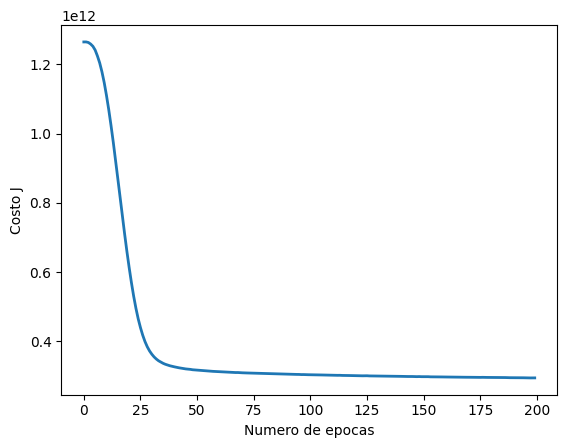

In [ ]:
# Gráfica de convergencia - equivalente a J_history del código original
pyplot.plot(np.arange(len(train_losses)), train_losses, lw=2)
pyplot.xlabel('Numero de epocas')
pyplot.ylabel('Costo J')
pyplot.show()

## Guardar Modelo

In [ ]:
# guardar solo pesos
PATH = './checkpoint.pt'
torch.save(model.state_dict(), PATH)

# cargar pesos
model.load_state_dict(torch.load(PATH, weights_only=True))
model.eval()

# guardar modelo completo
torch.save(model, 'model.pt')

# cargar modelo completo
model = torch.load('model.pt', weights_only=False)
model.eval()

ModeloPersonalizado(
  (fc1): Linear(in_features=11, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

## Predicción nuevos datos

In [ ]:
X_array = [
    3,        # borough_x
    10001,    # zip_code
    1990,     # yearbuilt
    2000,     # lotarea
    1500,     # bldgarea
    1200,     # resarea
    0,        # comarea
    2,        # unitstotal
    2,        # numfloors
    40.7,     # latitude
    -73.9     # longitude
]

# Normalizar con los mismos mu y sigma del entrenamiento
X_array = ((np.array(X_array) - mu) / sigma).astype(np.float32)

tensor = torch.tensor(X_array).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    price = model(tensor).item()

print("Precio predicho:", price)

Precio predicho: 388510.0


In [ ]:
# TorchScript (tracing)
x = torch.randn(1, D_in)
traced_model = torch.jit.trace(model.cpu(), x)
traced_model.save('model.zip')

loaded_model = torch.jit.load('model.zip')

In [ ]:
scripted_model = torch.jit.script(model.cpu())
scripted_model.save('model.zip')

loaded_model = torch.jit.load('model.zip')

In [ ]:
!pip install onnx onnxscript

In [ ]:
x = torch.randn(1, D_in)

torch.onnx.export(model.cpu(),
                  x,
                  "model.onnx",
                  export_params=True,
                  opset_version=10,
                  do_constant_folding=True,
                  input_names=['input'],
                  output_names=['output'],
                  dynamic_axes={'input':  {0: 'batch_size'},
                                'output': {0: 'batch_size'}})

/tmp/ipykernel_39640/2817503493.py:3: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(model.cpu(),
W0330 01:59:43.832000 39640 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 10 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0330 01:59:44.321000 39640 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio:

[torch.onnx] Obtain model graph for `ModeloPersonalizado([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ModeloPersonalizado([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[batch_size,11]>
            ),
            outputs=(
                %"output"<FLOAT,[batch_size,1]>
            ),
            initializers=(
                %"fc1.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"fc2.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"fc3.weight"<FLOAT,[1,64]>{TorchTensor(...)},
                %"fc3.bias"<FLOAT,[1]>{TorchTensor<FLOAT,[1]>(Parameter containing: tensor([2.6263], requires_grad=True), name='fc3.bias')},
                %"fc1.weight"<FLOAT,[128,11]>{TorchTensor(...)},
                %"fc2.weight"<FLOAT,[64,128]>{TorchTensor(...)}
            ),
        ) {
            0 |  # node_linear
    

## Test

In [ ]:
# predicciones del modelo PyTorch sobre el 20% de test
model.to(device)
model.eval()
with torch.no_grad():
    X_test_t = torch.from_numpy(X_test).float().to(device)
    y_pred_pytorch = model(X_test_t).cpu().numpy().flatten()

print("Primeras 10 predicciones vs valores reales:")
print(f"{'Real':>15}  {'Predicho':>15}  {'Diferencia':>15}")
for real, pred in zip(y_test[:10], y_pred_pytorch[:10]):
    print(f"{real:>15,.0f}  {pred:>15,.0f}  {abs(real - pred):>15,.0f}")

Primeras 10 predicciones vs valores reales:
           Real         Predicho       Diferencia
        699,000          993,730          294,730
        800,000          977,926          177,926
      1,670,000          942,487          727,513
      1,230,000        1,005,337          224,663
      1,192,000        1,005,284          186,716
      1,075,000        1,005,554           69,446
      1,005,993        1,004,476            1,517
      1,050,000        1,032,067           17,933
        849,000          987,753          138,753
        998,000          978,537           19,463


In [ ]:
mae = np.mean(np.abs(y_pred_pytorch - y_test))
print(f"MAE: ${mae:,.0f}")

# porcentaje de aciertos dentro del ±20% del precio real
margen = 0.20
aciertos = np.mean(np.abs(y_pred_pytorch - y_test) / y_test <= margen) * 100
print(f"Aciertos (±20%): {aciertos:.2f}%")

MAE: $305,369
Aciertos (±20%): 31.21%


In [ ]:
for margen in [0.10, 0.20, 0.30, 0.50, 1.00]:
    aciertos = np.mean(np.abs(y_pred_pytorch - y_test) / y_test <= margen) * 100
    print(f"Aciertos (±{int(margen*100)}%): {aciertos:.2f}%")

Aciertos (±10%): 15.88%
Aciertos (±20%): 31.21%
Aciertos (±30%): 46.34%
Aciertos (±50%): 71.32%
Aciertos (±100%): 92.14%


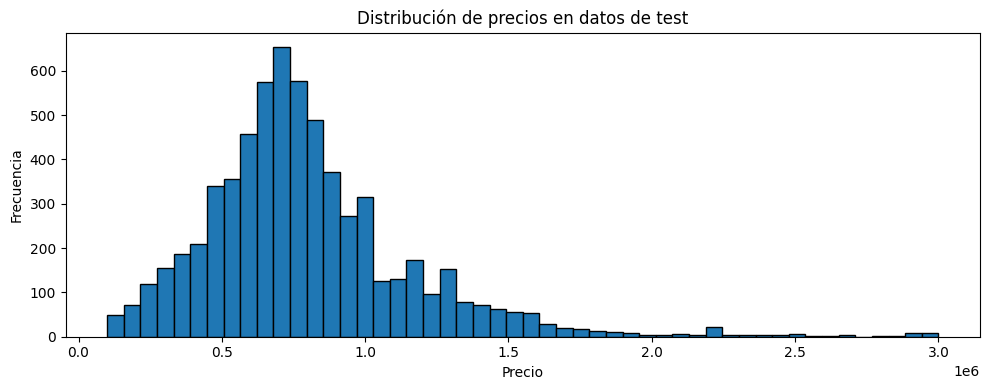

Precio mínimo:  $100,000
Precio máximo:  $3,000,000
Precio promedio: $798,859
Precio mediana:  $740,000


In [ ]:
pyplot.figure(figsize=(10, 4))
pyplot.hist(y_test, bins=50, edgecolor='black')
pyplot.xlabel('Precio')
pyplot.ylabel('Frecuencia')
pyplot.title('Distribución de precios en datos de test')
pyplot.tight_layout()
pyplot.show()

print(f"Precio mínimo:  ${y_test.min():,.0f}")
print(f"Precio máximo:  ${y_test.max():,.0f}")
print(f"Precio promedio: ${y_test.mean():,.0f}")
print(f"Precio mediana:  ${np.median(y_test):,.0f}")

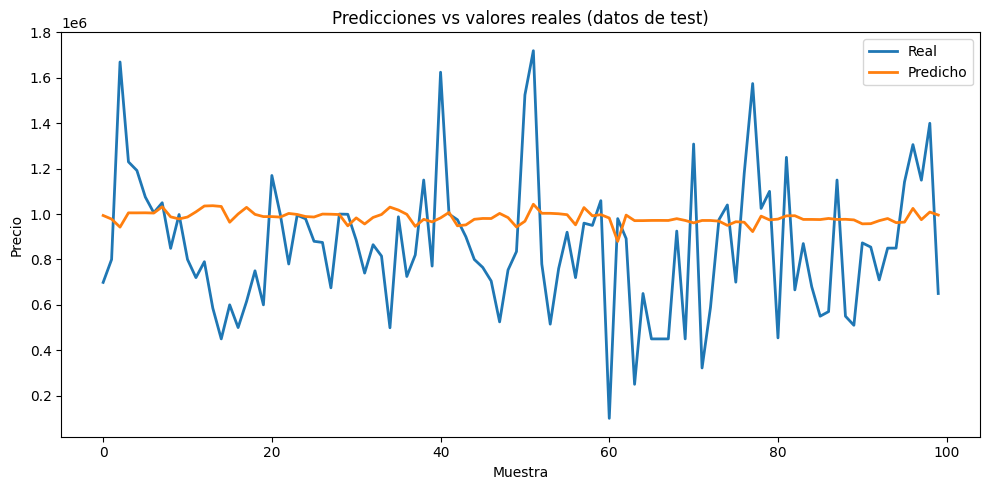

In [ ]:
pyplot.figure(figsize=(10, 5))
pyplot.plot(y_test[:100],         label='Real',     lw=2)
pyplot.plot(y_pred_pytorch[:100], label='Predicho', lw=2)
pyplot.xlabel('Muestra')
pyplot.ylabel('Precio')
pyplot.title('Predicciones vs valores reales (datos de test)')
pyplot.legend()
pyplot.tight_layout()
pyplot.show()